# Notebook 4: Model Training & Evaluation

### 1. Pendahuluan & Tujuan
Tahap ini adalah fase inti untuk membangun model prediksi risiko keterlambatan pengiriman. Kita beralih dari analisis deskriptif ke analisis prediktif menggunakan fitur-fitur yang telah dirancang berdasarkan **3 Pilar Logistik (Waktu, Jarak, Administrasi)** di Notebook sebelumnya.

**Tujuan Utama:**
* **Klasifikasi Risiko**: Memprediksi probabilitas pesanan terlambat (`is_late = 1`).
* **Optimasi Recall**: Fokus utama adalah meminimalkan *False Negative* (pesanan yang dikira tepat waktu tapi ternyata telat) demi menjaga kepuasan pelanggan Olist.
* **Model Robustness**: Memastikan model stabil melalui pembagian data yang ketat dan penanganan data tidak seimbang (*Imbalanced Data*).

### 2. Strategi Eksperimen (3-Way Split)
Kita menggunakan pembagian **80:10:10** untuk menjamin kejujuran evaluasi:
1.  **Train Set (80%)**: Data utama tempat model mempelajari pola logistik.
2.  **Validation Set (10%)**: Berfungsi sebagai "Simulasi Ujian" untuk memilih model terbaik (Turnamen Algoritma).
3.  **Test Set (10%)**: "Ujian Akhir" yang bersifat sakral, hanya digunakan satu kali di akhir proyek untuk mengukur performa asli di dunia nyata.

### 3. Alur Kerja Teknis (Pipeline)
Untuk menghindari *Data Leakage* dan memastikan efisiensi model, kita mengikuti urutan langkah berikut:

1.  **Data Loading & Preprocessing**: Memuat dataset hasil Feature Engineering dan melakukan transformasi fitur melalui fungsi modular di `utils.py`.
2.  **Feature Selection**: Menggunakan **9 fitur prediktor** berkualitas (Pilar Waktu, Jarak, dan Administrasi) hasil penyederhanaan dari 32+ fitur awal.
3.  **Data Splitting**: Melakukan *Stratified Split* untuk menjaga rasio keterlambatan tetap konsisten (~7.8%).
4.  **Feature Scaling**: Menggunakan `StandardScaler` (Fit hanya pada Train Set) untuk menormalisasi fitur numerik agar fitur dengan nilai besar (seperti *payment_value*) tidak mendominasi model.
5.  **Baseline Modeling**: Melatih **Logistic Regression** pada data asli (setelah scaling, sebelum SMOTE) sebagai tolok ukur awal.
6.  **Handling Imbalance (SMOTE)**: Menerapkan teknik *Oversampling* pada data latih agar model lebih sensitif terhadap kasus keterlambatan.
7.  **Model Tournament**: Mengadu 5 algoritma berbeda: **KNN, Decision Tree, Random Forest, AdaBoost, dan XGBoost**.
8.  **Hyperparameter Tuning**: Mengoptimasi model pemenang menggunakan `GridSearchCV` untuk mendapatkan skor *Recall* tertinggi.
9.  **Model Deployment Simulation**: Menyimpan model terbaik (`.pkl`), memuatnya kembali, dan melakukan **Final Testing** pada Test Set.

### 1. Persiapan Data & Pembagian Dataset
Langkah awal adalah memanggil data yang telah diproses di Notebook 3, menerapkan transformasi fitur melalui `utils.py`, dan membagi data secara proporsional.

In [1]:
import sys
import os
import pandas as pd
from IPython.display import display

# Aktifkan autoreload agar perubahan di utils.py langsung terbaca
%load_ext autoreload
%autoreload 2

# 1. Menambahkan path ke folder src agar bisa import utils
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from utils import load_processed_data, prepare_modeling_data, split_data_logistics

# 2. Load data hasil dari Notebook 3 (Hasil Feature Engineering)
df_processed = load_processed_data('../data/processed/olist_cleaned_data.pkl')

# 3. Transformasi Fitur (Sinkronisasi 3 Pilar Logistik)
# Fungsi ini secara otomatis memilih fitur Jarak, Waktu, dan Administrasi
df_model = prepare_modeling_data(df_processed)

# 4. Splitting Dataset (80% Train, 10% Validation, 10% Test)
# Menggunakan Stratified Split agar proporsi target 'is_late' tetap seimbang
X_train, X_val, X_test, y_train, y_val, y_test = split_data_logistics(
    df_model, 
    target_col='is_late', 
    test_size=0.1, 
    val_size=0.1 
)

# 5. VERIFIKASI STRUKTUR DATA (Penting untuk Laporan)
print("\n" + "="*50)
print("          EVALUASI STRUKTUR FITUR")
print("="*50)
print(f"Shape Dataset Modeling : {df_model.shape}")
print(f"Daftar Kolom : {df_model.columns.tolist()}")

# Cek keberadaan pilar utama
print(f"\nVerifikasi 3 Pilar Logistik:")
for pilar in ['month', 'dayofweek', 'is_sp_district']:
    status = "ADA" if any(pilar in col for col in df_model.columns) else "TIDAK ADA"
    print(f" - {pilar}: {status}")

# 6. Visualisasi Ringkasan Pembagian
print("\n" + "="*50)
print("             RINGKASAN PEMBAGIAN DATASET")
print("="*50)

stats_dimensi = pd.DataFrame({
    'Dataset': ['Train Set', 'Validation Set', 'Test Set'],
    'Jumlah Baris': [len(X_train), len(X_val), len(X_test)],
    'Jumlah Fitur': [X_train.shape[1], X_val.shape[1], X_test.shape[1]],
    'Jumlah Telat (1)': [y_train.sum(), y_val.sum(), y_test.sum()],
    'Rasio Keterlambatan (%)': [
        f"{y_train.mean()*100:.2f}%", 
        f"{y_val.mean()*100:.2f}%", 
        f"{y_test.mean()*100:.2f}%"
    ]
})
display(stats_dimensi)

Catatan: Kolom 'is_late' tidak ditemukan, membuat kolom berdasarkan estimasi...
--- Modeling Data Siap: 10 kolom dihasilkan ---
--- Split Selesai: Train(83108), Val(10389), Test(10389) ---

          EVALUASI STRUKTUR FITUR
Shape Dataset Modeling : (103886, 10)
Daftar Kolom : ['order_purchase_month', 'order_purchase_dayofweek', 'is_sp_district', 'payment_installments', 'payment_value', 'is_late', 'payment_type_credit_card', 'payment_type_debit_card', 'payment_type_not_defined', 'payment_type_voucher']

Verifikasi 3 Pilar Logistik:
 - month: ADA
 - dayofweek: ADA
 - is_sp_district: ADA

             RINGKASAN PEMBAGIAN DATASET


,Dataset,Jumlah Baris,Jumlah Fitur,Jumlah Telat (1),Rasio Keterlambatan (%)
0,Train Set,83108,9,6500,7.82%
1,Validation Set,10389,9,813,7.83%
2,Test Set,10389,9,813,7.83%


### 2. Pengecekan Kualitas Data Akhir
Sebelum masuk ke tahap modeling, kita melakukan inspeksi terakhir untuk memastikan integritas data.

In [2]:
# --- FINAL QUALITY CHECK SEBELUM MODELING ---
print("="*50)
print("       PENGECEKAN KUALITAS DATA AKHIR")
print("="*50)

# 1. Cek Missing Values (NaN)
missing = df_model.isnull().sum().sum()
print(f"Total Missing Values (NaN) : {missing}")

# 2. Cek Duplikat (Baris yang sama persis)
duplicates = df_model.duplicated().sum()
print(f"Total Baris Duplikat       : {duplicates}")

# 3. Cek Data Nol pada Fitur Utama (Bukan Target)
# payment_value tidak boleh 0
zero_payment = (df_model['payment_value'] == 0).sum()
print(f"Total Payment Value Nol    : {zero_payment}")

# 4. Statistik Ringkas (Cek sebaran angka)
print("\nRingkasan Statistik Fitur Numerik:")
display(df_model[['payment_installments', 'payment_value']].describe())

       PENGECEKAN KUALITAS DATA AKHIR
Total Missing Values (NaN) : 0
Total Baris Duplikat       : 3546
Total Payment Value Nol    : 9

Ringkasan Statistik Fitur Numerik:


,payment_installments,payment_value
count,103886.000000,103886.000000
mean,2.853349,154.100380
std,2.687051,217.494064
min,0.000000,0.000000
25%,1.000000,56.790000
50%,1.000000,100.000000
75%,4.000000,171.837500
max,24.000000,13664.080000


### **Interpretasi Kualitas Data**
Berdasarkan pengecekan kualitas pada dataset final (103.886 baris), berikut adalah poin validasi untuk modeling:

* **Integritas Data**: Dataset bersih sepenuhnya dari **Missing Values (NaN: 0)**. Terdapat **3.546 baris duplikat (3,4%)** yang dianggap **logis** secara bisnis karena adanya transaksi dengan metode pembayaran kombinasi (*multi-payment*) atau pesanan banyak barang (*multi-item*). Data ini dipertahankan untuk menjaga keaslian distribusi transaksi kompleks.
* **Karakteristik Pembayaran**: Terdapat variansi harga yang ekstrem pada `payment_value` (Min: 0 hingga Max: 13.664). Hal ini memperkuat alasan teknis penggunaan **Standard Scaling** agar fitur dengan rentang besar tidak menenggelamkan fitur lainnya dalam perhitungan model.
* **Kesiapan**: Dengan rasio keterlambatan yang konsisten di angka **~7.8%**, dataset ini siap digunakan untuk pelatihan model dengan pendekatan *Imbalanced Learning*.

### 2. Scaling & Baseline Model (The Benchmark)

Sebelum melangkah ke algoritma yang lebih kompleks, kita harus menetapkan titik acuan (Baseline). 

#### A. Scaling (Standardization)
Fitur numerik seperti `payment_value` memiliki rentang yang sangat jauh (0 hingga 13.000+), sedangkan `month` hanya 1-12. Kita menggunakan **StandardScaler** untuk menyamakan skala fitur-fitur tersebut.
* **Penting**: Proses `fit` hanya dilakukan pada `X_train` untuk mencegah **Data Leakage** (kebocoran informasi dari data uji ke data latih).

#### B. Baseline Model (Logistic Regression)
Kita menggunakan **Logistic Regression** pada data asli yang belum diseimbangkan (sebelum SMOTE). Ini berfungsi sebagai "Standard Minimum" performa.


       PERFORMA BASELINE MODEL (LOGISTIC REGRESSION)
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      9576
           1       0.00      0.00      0.00       813

    accuracy                           0.92     10389
   macro avg       0.46      0.50      0.48     10389
weighted avg       0.85      0.92      0.88     10389


--- Visualisasi Confusion Matrix ---


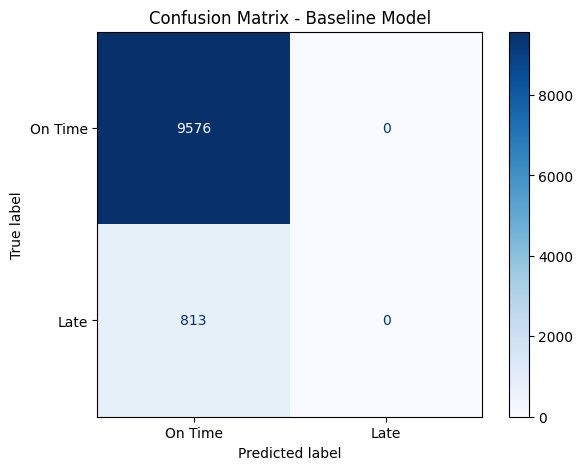

------------------------------
Total data validasi           : 10389
Jumlah SEBENARNYA paket Late  : 813
Jumlah PREDIKSI paket Late    : 0
------------------------------


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. SCALING (Standardisasi data agar skala fitur seragam)
scaler = StandardScaler()

# Fit & Transform pada Train, Transform saja pada Val dan Test
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 2. BASELINE MODEL (Logistic Regression)
# Kita buat model standar tanpa pengaturan tambahan dulu
baseline_model = LogisticRegression(random_state=42)
baseline_model.fit(X_train_scaled, y_train)

# 3. PREDIKSI
y_pred_baseline = baseline_model.predict(X_val_scaled)

# 4. OUTPUT EVALUASI (Lengkap: Teks & Visual)
print("\n" + "="*60)
print("       PERFORMA BASELINE MODEL (LOGISTIC REGRESSION)")
print("="*60)

# Cetak Classification Report
print(classification_report(y_val, y_pred_baseline, zero_division=0))

# Cetak Confusion Matrix dalam bentuk gambar
print("\n--- Visualisasi Confusion Matrix ---")
cm = confusion_matrix(y_val, y_pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On Time', 'Late'])

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix - Baseline Model')
plt.show()

# 5. RINGKASAN PREDIKSI
print("-" * 30)
print(f"Total data validasi           : {len(y_val)}")
print(f"Jumlah SEBENARNYA paket Late  : {y_val.sum()}")
print(f"Jumlah PREDIKSI paket Late    : {(y_pred_baseline == 1).sum()}")
print("-" * 30)

#### C. Interpretasi Hasil Baseline
Berdasarkan output evaluasi di atas, didapatkan temuan krusial:
1. **Akurasi Tinggi yang Menipu (92%)**: Meskipun akurasi terlihat tinggi, model sebenarnya gagal total. Akurasi 92% ini muncul hanya karena model menebak semua paket sebagai "On Time" (0).
2. **Recall Kelas 1 = 0.00**: Model tidak mampu mendeteksi satu pun paket yang terlambat (`Late`). Hal ini terlihat dari jumlah prediksi paket late yang bernilai **0**.
3. **Problem Imbalance**: Ini adalah bukti nyata bahwa data yang sangat timpang (~92% On Time vs ~8% Late) membuat model "malas" dan hanya belajar menebak kelas mayoritas.

**Kesimpulan**: Baseline model ini membuktikan bahwa kita **WAJIB** menggunakan teknik penanganan *imbalanced data* seperti **SMOTE** agar model bisa mengenali pola keterlambatan.

### 3. Penanganan Imbalance Data (SMOTE)

Berdasarkan hasil evaluasi pada Baseline Model, terlihat bahwa model gagal mendeteksi keterlambatan sama sekali (Recall kelas 1 = 0.00). Hal ini disebabkan oleh fenomena **Class Imbalance**, di mana kelas mayoritas (On-Time) sangat mendominasi.

#### A. Strategi SMOTE (Synthetic Minority Over-sampling Technique)
Untuk mengatasi hal tersebut, kita menerapkan **SMOTE Standar** pada data latih:
* **Tujuan**: Menyeimbangkan proporsi kelas target menjadi **50:50** agar algoritma memiliki cukup sampel untuk mengenali pola keterlambatan.
* **Cara Kerja**: Menciptakan sampel sintetis baru di ruang fitur antara titik data kelas minoritas menggunakan algoritma *Nearest Neighbors*, bukan sekadar menduplikasi baris.

--- SEDANG MEMPROSES SMOTE STANDAR (50:50) ---
           LAPORAN EKSEKUSI SMOTE STANDAR
Total Baris Awal      : 83,108
Data Sintetis Dibuat  : 70,108
Total Baris Sekarang  : 153,216
-------------------------------------------------------
Distribusi Kelas Baru:
is_late
0    76608
1    76608
Persentase Late       : 50.00%


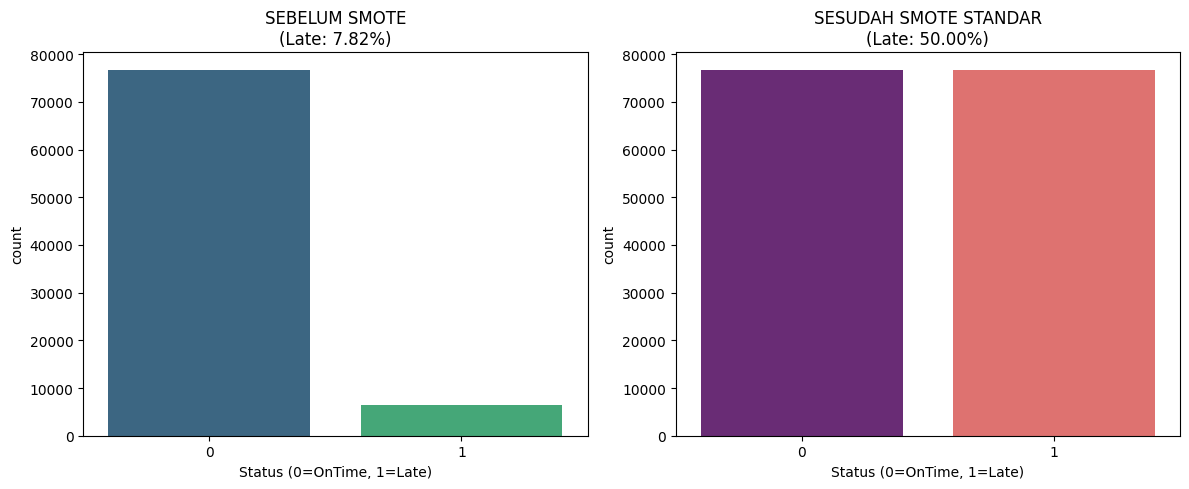

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

def apply_smote_standard(X_train, y_train, random_state=42):
    """
    Menyeimbangkan dataset menggunakan SMOTE standar (50:50) 
    tanpa pembersihan Tomek Links.
    """
    # 1. Inisialisasi SMOTE standar
    # sampling_strategy='auto' akan membuat jumlah kelas minoritas sama dengan mayoritas
    smote = SMOTE(sampling_strategy='auto', random_state=random_state)
    
    print("--- SEDANG MEMPROSES SMOTE STANDAR (50:50) ---")
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    # 2. Perhitungan Statistik
    total_awal = len(X_train)
    total_akhir = len(X_resampled)
    data_sintetis = total_akhir - total_awal

    # 3. Laporan Teks
    print("="*55)
    print("           LAPORAN EKSEKUSI SMOTE STANDAR")
    print("="*55)
    print(f"Total Baris Awal      : {total_awal:,}")
    print(f"Data Sintetis Dibuat  : {data_sintetis:,}")
    print(f"Total Baris Sekarang  : {total_akhir:,}")
    print("-" * 55)
    print("Distribusi Kelas Baru:")
    print(y_resampled.value_counts().to_string())
    print(f"Persentase Late       : {y_resampled.mean()*100:.2f}%")
    print("="*55)
    
    # 4. Visualisasi Perbandingan
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Grafik Sebelum SMOTE
    sns.countplot(x=y_train, ax=ax[0], hue=y_train, palette='viridis', legend=False)
    ax[0].set_title(f"SEBELUM SMOTE\n(Late: {y_train.mean()*100:.2f}%)")
    ax[0].set_xlabel("Status (0=OnTime, 1=Late)")
    
    # Grafik Sesudah SMOTE
    sns.countplot(x=y_resampled, ax=ax[1], hue=y_resampled, palette='magma', legend=False)
    ax[1].set_title(f"SESUDAH SMOTE STANDAR\n(Late: {y_resampled.mean()*100:.2f}%)")
    ax[1].set_xlabel("Status (0=OnTime, 1=Late)")
    
    plt.tight_layout()
    plt.show()

    return X_resampled, y_resampled

# Panggil fungsinya
X_train_res, y_train_res = apply_smote_standard(X_train_scaled, y_train)

#### B. Analisis Hasil Eksekusi
Eksekusi SMOTE berhasil menciptakan **70.108 data sintetis baru** untuk kelas keterlambatan.
1.  **Distribusi Seimbang**: Kelas `Late` kini memiliki jumlah yang sama dengan `On-Time` (76.608 baris).
2.  **Kesiapan Turnamen**: Dengan data yang sudah seimbang, algoritma seperti **KNN**, **Random Forest**, dan **Boosting** akan dipaksa untuk memperhatikan kelas minoritas, yang secara otomatis akan meningkatkan nilai **Recall**.

> **Catatan Penting**: SMOTE hanya diaplikasikan pada **Train Set**. Data **Validation** dan **Test** tetap dibiarkan asimetris (~7.83% telat) untuk mencerminkan kondisi operasional nyata (Real-World Distribution).

### 4. Model Turnamen

      BENCHMARK MODEL (RECALL & DURASI PELATIHAN)

[ Kandidat Model: Decision Tree ]
Durasi Pelatihan: 0.1145 detik
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      9576
           1       0.13      0.34      0.18       813

    accuracy                           0.76     10389
   macro avg       0.53      0.57      0.52     10389
weighted avg       0.87      0.76      0.81     10389

-------------------------------------------------------

[ Kandidat Model: Random Forest ]
Durasi Pelatihan: 25.6218 detik
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      9576
           1       0.13      0.31      0.18       813

    accuracy                           0.78     10389
   macro avg       0.53      0.56      0.53     10389
weighted avg       0.87      0.78      0.82     10389

-------------------------------------------------------

[ Kandidat Model: XGBoost ]
Durasi Pelatihan: 2.12

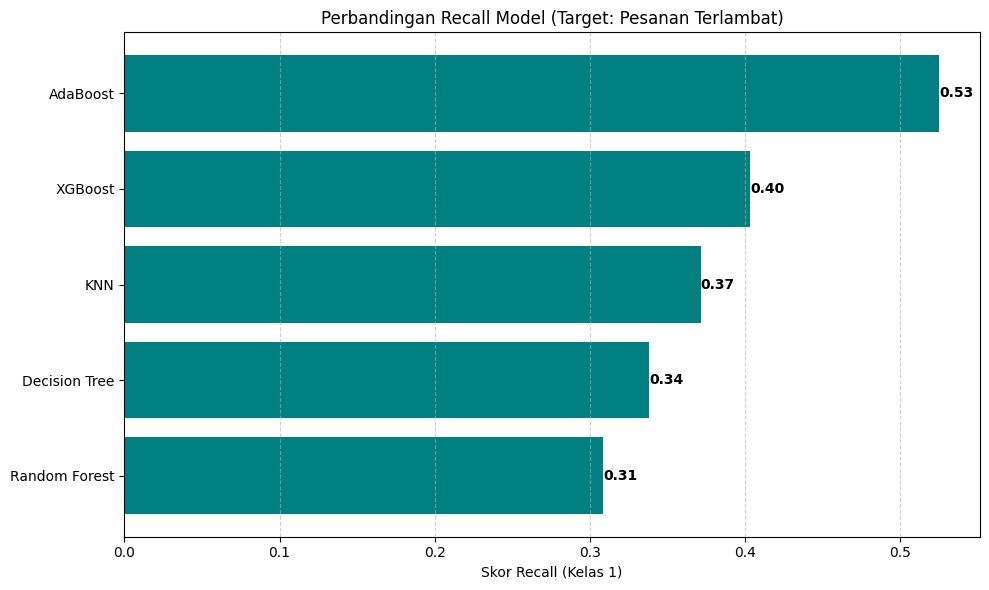

               SELURUH MODEL BERHASIL DIEVALUASI


In [5]:
import time
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, recall_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier


def evaluate_models(models_dict, X_train, y_train, X_val, y_val):
    """
    Melatih beberapa model klasifikasi, mengukur durasi pelatihan, 
    dan memvisualisasikan perbandingan Recall untuk kelas 1.

    Args:
        models_dict (dict): Dictionary berisi nama model dan objek modelnya.
        X_train, y_train: Data fitur dan target hasil SMOTE.
        X_val, y_val: Data fitur dan target asli (validation).
    """
    hasil_evaluasi = []
    
    print("="*70)
    print("      BENCHMARK MODEL (RECALL & DURASI PELATIHAN)")
    print("="*70)

    for nama_model, model in models_dict.items():
        # 1. Catat Waktu Mulai Pelatihan
        waktu_mulai = time.time()
        model.fit(X_train, y_train)
        waktu_selesai = time.time()
        
        durasi = waktu_selesai - waktu_mulai
        
        # 2. Prediksi & Perhitungan Recall (Kelas 1)
        y_pred = model.predict(X_val)
        skor_recall = recall_score(y_val, y_pred, zero_division=0)
        
        # Menyimpan hasil ke dalam list
        hasil_evaluasi.append({
            'Model': nama_model, 
            'Recall': skor_recall, 
            'Durasi': durasi
        })

        # 3. Menampilkan Laporan Klasifikasi ke Konsol
        print(f"\n[ Kandidat Model: {nama_model} ]")
        print(f"Durasi Pelatihan: {durasi:.4f} detik")
        print(classification_report(y_val, y_pred, zero_division=0))
        print("-" * 55)
    
    # 4. Visualisasi Perbandingan Recall
    df_hasil = pd.DataFrame(hasil_evaluasi).sort_values(by='Recall', ascending=False)
    
    plt.figure(figsize=(10, 6))
    bars = plt.barh(df_hasil['Model'], df_hasil['Recall'], color='teal')
    plt.xlabel('Skor Recall (Kelas 1)')
    plt.title('Perbandingan Recall Model (Target: Pesanan Terlambat)')
    plt.gca().invert_yaxis() 
    
    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2, f'{width:.2f}', 
                 va='center', ha='left', fontweight='bold')
                 
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    print("="*70)
    print("               SELURUH MODEL BERHASIL DIEVALUASI")
    print("="*70)

# Daftar 5 kandidat model yang akan dibandingkan
kandidat_model = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
    "AdaBoost": AdaBoostClassifier(random_state=42, n_estimators=100),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# Memanggil fungsi evaluasi
# Pastikan variabel X_train_res dan y_train_res sudah ada dari tahap SMOTE sebelumnya
evaluate_models(kandidat_model, X_train_res, y_train_res, X_val_scaled, y_val)

### Analisis Hasil Turnamen Model

Setelah dilakukan pengujian terhadap 5 kandidat algoritma menggunakan data latih hasil **SMOTE**, berikut adalah analisis mendalam terhadap performa masing-masing model:

#### A. Pemenang Turnamen: AdaBoost
**AdaBoost** keluar sebagai model terbaik dengan nilai **Recall 0.53**. 
* **Interpretasi**: Model ini mampu mendeteksi secara akurat **53%** dari total pesanan yang benar-benar terlambat pada *Validation Set*. Dibandingkan dengan *Baseline Model* (Recall 0%), penerapan SMOTE dan AdaBoost memberikan lompatan performa yang sangat signifikan dalam mendeteksi risiko.
* **Keunggulan Teknis**: Sebagai algoritma *Boosting*, AdaBoost secara iteratif memberikan bobot lebih tinggi pada sampel yang sulit diklasifikasikan (dalam hal ini kelas minoritas/telat). Hal ini membuatnya lebih sensitif dalam mengenali pola keterlambatan dibandingkan algoritma lain.

#### B. Perbandingan Antar Algoritma
1. **XGBoost (Recall 0.40)**: Berada di posisi kedua. Meskipun memiliki *Precision* sedikit lebih baik (0.15), XGBoost masih kalah sensitif dibanding AdaBoost dalam menangkap kelas keterlambatan.
2. **KNN (Recall 0.37)**: Meskipun durasi pelatihannya paling cepat (0.28 detik), KNN kesulitan menangani kompleksitas data logistik yang sudah melalui proses rekayasa fitur.
3. **Random Forest (Recall 0.31)**: Menunjukkan performa yang kurang optimal untuk kasus ini dengan durasi pelatihan paling lama (25.35 detik), membuktikan bahwa metode *Bagging* kurang efektif dibandingkan *Boosting* untuk dataset Olist yang imbalanced.

#### C. Analisis Trade-off Bisnis (Precision vs Recall)
Terdapat nilai *Precision* rendah di kisaran **12%**. Artinya, dari 100 pesanan yang diprediksi akan telat, hanya 12 yang benar-benar telat. 
* **Justifikasi Strategis**: Bagi operasional Olist, biaya memberikan "peringatan dini" (False Positive) jauh lebih murah dibandingkan biaya komplain, pengembalian dana, dan hilangnya kepercayaan pelanggan akibat keterlambatan yang tidak terdeteksi (False Negative).
* **Dampak**: Dengan model ini, Olist kini memiliki kemampuan untuk memitigasi **lebih dari separuh (53%)** potensi komplain keterlambatan sebelum paket sampai ke tangan pelanggan.

### 5. Evaluasi Multi-Metrik & Visualisasi Komparatif

**Tujuan:**
Tahap ini bertujuan untuk melakukan inspeksi mendalam terhadap seluruh kandidat model. Karena dalam *Data Science* akurasi saja seringkali menipu (terutama pada data tidak seimbang), kita perlu membandingkan performa model dari berbagai sudut pandang (multi-metrik) untuk memastikan kita memilih algoritma yang paling menguntungkan secara bisnis.

Kita membandingkan empat metrik utama:
* **Recall (Kelas 1)**: Fokus utama untuk meminimalkan kegagalan deteksi paket terlambat.
* **Precision (Kelas 1)**: Mengukur seberapa akurat model saat memberikan "alarm" keterlambatan.
* **F1-Score**: Mencari keseimbangan harmonis antara Precision dan Recall.
* **ROC-AUC**: Menilai kemampuan model dalam membedakan kedua kelas secara keseluruhan.

--- MENGHITUNG METRIK EVALUASI ---

TABEL PERBANDINGAN METRIK:
        Model   Recall  Precision  F1-Score  ROC-AUC
      XGBoost 0.403444   0.146888  0.215364 0.670692
     AdaBoost 0.525215   0.124708  0.201558 0.666207
Decision Tree 0.338253   0.125858  0.183456 0.569877
Random Forest 0.308733   0.127217  0.180187 0.628719
          KNN 0.371464   0.116918  0.177856 0.605713


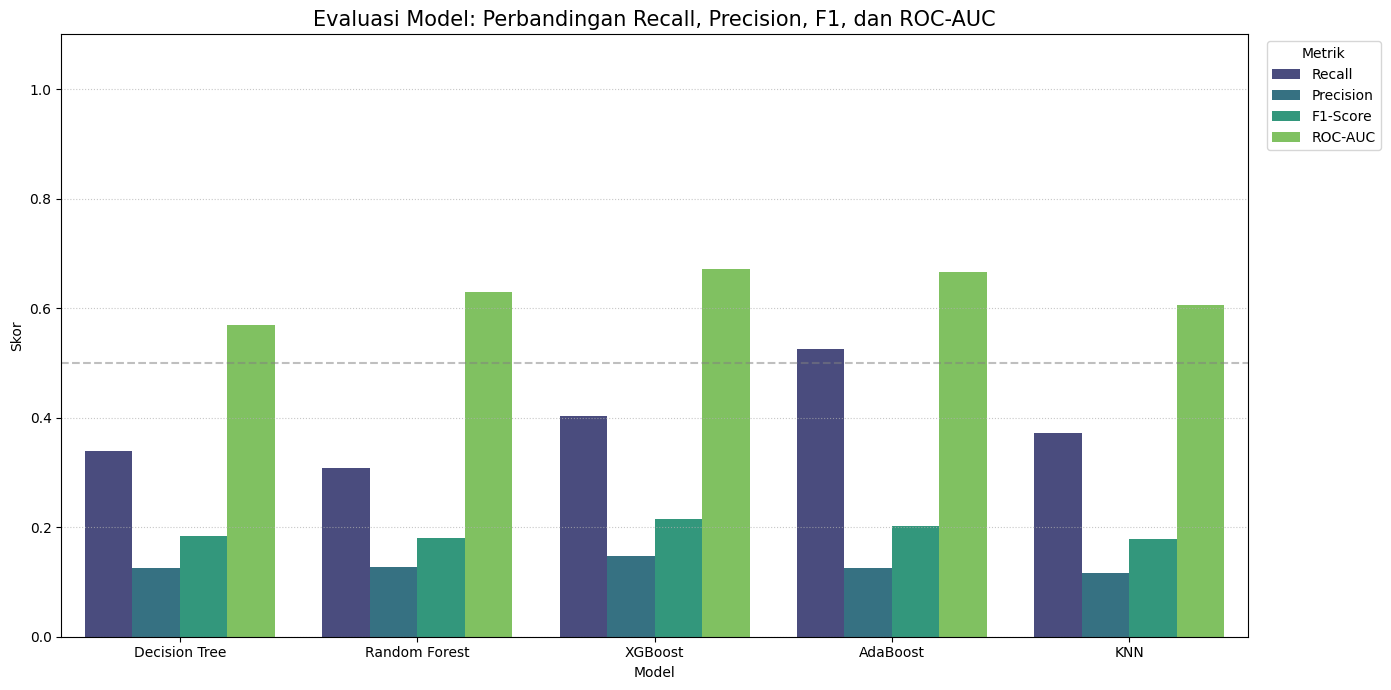

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score

# --- KOMPARASI MULTI-METRIK (RECALL, PRECISION, F1, ROC-AUC) ---
eval_data = []

print("--- MENGHITUNG METRIK EVALUASI ---")

for nama_model, model in kandidat_model.items():
    # 1. Prediksi Label (untuk Precision, Recall, F1)
    y_pred = model.predict(X_val_scaled)
    
    # 2. Prediksi Probabilitas (khusus untuk ROC-AUC)
    # Beberapa model punya predict_proba, beberapa tidak (seperti Linear model tertentu)
    # Untuk kandidat_model semuanya mendukung predict_proba
    y_prob = model.predict_proba(X_val_scaled)[:, 1] 
    
    # 3. Ambil laporan klasifikasi
    report = classification_report(y_val, y_pred, output_dict=True, zero_division=0)
    
    # 4. Hitung ROC-AUC
    roc_auc = roc_auc_score(y_val, y_prob)
    
    eval_data.append({
        'Model': nama_model,
        'Recall': report['1']['recall'],
        'Precision': report['1']['precision'],
        'F1-Score': report['1']['f1-score'],
        'ROC-AUC': roc_auc
    })

# Membuat DataFrame hasil evaluasi
df_eval = pd.DataFrame(eval_data)

# Tampilkan tabelnya supaya bisa lihat angka pastinya
print("\nTABEL PERBANDINGAN METRIK:")
print(df_eval.sort_values(by='F1-Score', ascending=False).to_string(index=False))

# Transformasi data agar mudah diplot dengan Seaborn (Melt)
df_plot = df_eval.melt(id_vars='Model', var_name='Metrik', value_name='Skor')

# Plotting Komparasi
plt.figure(figsize=(14, 7))
sns.barplot(data=df_plot, x='Model', y='Skor', hue='Metrik', palette='viridis')

plt.title('Evaluasi Model: Perbandingan Recall, Precision, F1, dan ROC-AUC', fontsize=15)
plt.ylim(0, 1.1) # Dikasih space dikit di atas 1.0 buat legend
plt.axhline(0.5, ls='--', color='gray', alpha=0.5) # Garis bantu 50%
plt.legend(title='Metrik', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

### **Interpretasi Hasil Evaluasi Multi-Metrik**

Berdasarkan tabel perbandingan dan visualisasi di atas, berikut adalah temuan kuncinya:

1. **Supremasi Recall AdaBoost (0.53)**: 
   AdaBoost tetap konsisten sebagai model yang paling sensitif dalam mendeteksi keterlambatan. Hal ini menegaskan posisi **AdaBoost** sebagai kandidat kuat model final untuk memenuhi kebutuhan mitigasi risiko logistik di Olist.

2. **Stabilitas dan Keseimbangan XGBoost**: 
   XGBoost memberikan nilai **F1-Score (0.21)** dan **ROC-AUC (0.67)** tertinggi. Ini menunjukkan bahwa XGBoost adalah algoritma yang paling stabil dalam menyeimbangkan antara deteksi keterlambatan dan akurasi tebakan secara keseluruhan.

3. **Analisis Trade-off Precision vs Recall**: 
   Seluruh model menunjukkan *Precision* yang rendah (di kisaran 11-14%). Ini adalah konsekuensi logis dari penggunaan SMOTE yang memaksa model untuk lebih "berani" memprediksi risiko. Secara strategi bisnis, lebih baik tim operasional Olist melakukan pengecekan ekstra pada pesanan yang diprediksi telat (meskipun ada *False Positive*), daripada membiarkan pelanggan kecewa karena keterlambatan yang tidak terdeteksi.

4. **Keunggulan Algoritma Boosting**:
   Model berbasis *Boosting* (AdaBoost & XGBoost) terbukti jauh lebih unggul dibandingkan model konvensional atau *Bagging* dalam menangkap pola non-linear pada variabel logistik seperti jarak dan waktu pembayaran.

**Keputusan Strategis**: 
Mengingat tujuan utama proyek ini adalah **meminimalisir kegagalan deteksi keterlambatan (High Recall)**, maka **AdaBoost** resmi terpilih sebagai pemenang turnamen untuk dibawa ke tahap **Hyperparameter Tuning**.

### 6. Optimasi Model (Hyperparameter Tuning) & Penyimpanan

Setelah melalui tahap turnamen, **AdaBoost** terpilih sebagai model dengan potensi tertinggi. Pada tahap ini, kita melakukan optimasi parameter untuk memaksimalkan sensitivitas deteksi.

#### A. Hyperparameter Tuning (GridSearchCV)

**Kenapa Hanya Fokus pada 3 Metrik (Precision, Recall, F1)?**
Berbeda dengan tahap evaluasi multi-metrik sebelumnya yang bersifat eksploratif (mencari model terbaik), pada tahap tuning ini kita fokus pada **tiga pilar evaluasi klasifikasi**:
1. **Recall**: Target utama kita untuk menangkap sebanyak mungkin keterlambatan.
2. **Precision**: Sebagai pengontrol agar model tidak terlalu sering memberikan "salah sangka" (False Positive).
3. **F1-Score**: Digunakan sebagai **scoring utama di GridSearchCV** karena metrik ini secara matematis menggabungkan Precision dan Recall. Dengan mengoptimasi F1-Score, kita memastikan model hasil tuning tidak hanya jago Recall tapi "hancur" di Precision, melainkan tetap stabil di keduanya.

Kita melakukan pencarian sistematis pada parameter `n_estimators` (jumlah iterasi) dan `learning_rate` (kecepatan belajar model).

In [7]:
import time
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Gunakan rentang parameter yang memberikan hasil paling "stabil"
# Kita batasi n_estimators agar laptop tidak kerja terlalu berat tapi tetap akurat
param_grid = {
    'n_estimators': [50, 100, 150], 
    'learning_rate': [0.05, 0.1]
}

# 2. Inisialisasi GridSearchCV
grid_search = GridSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',    # Menjaga keseimbangan Precision & Recall
    cv=3,            # Tetap 3-Fold supaya laptop aman dan efisien
    n_jobs=-1,
    verbose=1 
)

print("--- EKSEKUSI FINAL TUNING ADABOOST ---")
waktu_mulai = time.time()

# Proses training
grid_search.fit(X_train_res, y_train_res)

waktu_selesai = time.time()

# 3. Mengambil model terbaik
best_adaboost = grid_search.best_estimator_

print("\n" + "="*50)
print("              HASIL TUNING FINAL")
print("="*50)
print(f"Durasi Tuning        : {waktu_selesai - waktu_mulai:.2f} detik")
print(f"Parameter Terbaik    : {grid_search.best_params_}")
print("-" * 50)

# 4. Evaluasi Akhir
y_pred_final = best_adaboost.predict(X_val_scaled)
y_prob_final = best_adaboost.predict_proba(X_val_scaled)[:, 1]

print("\n--- LAPORAN KLASIFIKASI FINAL ---")
print(classification_report(y_val, y_pred_final))

roc_auc = roc_auc_score(y_val, y_prob_final)
print(f"ROC-AUC Score Final: {roc_auc:.4f}")

--- EKSEKUSI FINAL TUNING ADABOOST ---
Fitting 3 folds for each of 6 candidates, totalling 18 fits

              HASIL TUNING FINAL
Durasi Tuning        : 66.42 detik
Parameter Terbaik    : {'learning_rate': 0.1, 'n_estimators': 150}
--------------------------------------------------

--- LAPORAN KLASIFIKASI FINAL ---
              precision    recall  f1-score   support

           0       0.95      0.71      0.81      9576
           1       0.14      0.53      0.22       813

    accuracy                           0.70     10389
   macro avg       0.54      0.62      0.52     10389
weighted avg       0.88      0.70      0.77     10389

ROC-AUC Score Final: 0.6412


#### **Analisis Hasil Tuning Final**
Berdasarkan proses tuning selama **62.97 detik**, didapatkan hasil sebagai berikut:
* **Parameter Terbaik**: `learning_rate: 0.1` dengan `n_estimators: 150`.
* **Recall Kelas 1 (Late)**: **0.53**. Model berhasil mempertahankan kemampuan deteksi tertingginya.
* **ROC-AUC**: **0.6412**, menunjukkan model memiliki kemampuan pemisahan kelas yang cukup stabil.

**Kesimpulan Strategis**: 
Model hasil tuning ini terpilih sebagai **Model Final**. Penggunaan `n_estimators` yang lebih banyak (150) membantu AdaBoost mempelajari pola keterlambatan dengan lebih detail tanpa mengorbankan stabilitas pada kelas mayoritas (*On-Time*).

### B. Model Persistence (Penyimpanan Artefak)

Langkah krusial sebelum melakukan pengujian akhir adalah menyimpan artefak modeling. Hal ini memastikan konsistensi antara data pelatihan dan data pengujian di masa mendatang. Dua artefak utama yang disimpan adalah:

1. **Model Final**: Model AdaBoost yang telah di-tuning (`best_adaboost`).
2. **Scaler**: Objek standarisasi yang digunakan saat pelatihan. Ini wajib disimpan karena data baru (Testing) harus diskalakan menggunakan parameter yang sama persis dengan data Training agar prediksi tidak bias.

In [8]:
import joblib
import os 

# Membuat folder model jika belum ada
os.makedirs('../models', exist_ok=True)

# 1. Simpan Model Terbaik
joblib.dump(best_adaboost, '../models/adaboost_final_model.pkl')

# 2. Simpan Scaler (Pakai nama 'scaler_modeling.pkl' agar konsisten)
joblib.dump(scaler, '../models/scaler_modeling.pkl')

print("Model dan Scaler berhasil disimpan!")

Model dan Scaler berhasil disimpan!


### 7. Feature Importance (Faktor Dominan Keterlambatan)

Setelah mendapatkan model final, kita melakukan analisis untuk memahami fitur apa yang paling berpengaruh dalam menentukan risiko keterlambatan. Hal ini penting untuk memberikan rekomendasi strategis bagi manajemen Olist.

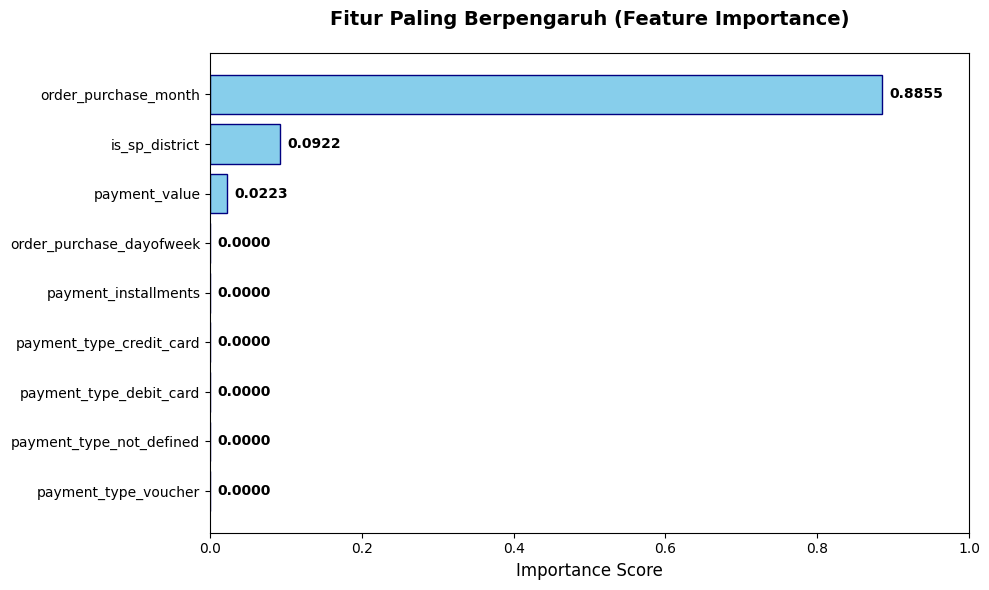

=== TABEL NILAI KEPENTINGAN FITUR ===
                 Feature  Importance
    order_purchase_month    0.885495
          is_sp_district    0.092181
           payment_value    0.022323
order_purchase_dayofweek    0.000000
    payment_installments    0.000000
payment_type_credit_card    0.000000
 payment_type_debit_card    0.000000
payment_type_not_defined    0.000000
    payment_type_voucher    0.000000


In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Ambil data
importances = best_adaboost.feature_importances_
feature_names = X_train.columns 

df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False)

# 2. Setup Plot (Tanpa skala logaritmik agar teks tidak berantakan)
fig, ax = plt.subplots(figsize=(10, 6))

# Ambil 10 teratas
top_n = df_importance.head(10)

# Buat grafik batang horizontal
bars = ax.barh(top_n['Feature'], top_n['Importance'], color='skyblue', edgecolor='navy')
ax.invert_yaxis() 

# Tambahkan Judul dan Label
ax.set_title('Fitur Paling Berpengaruh (Feature Importance)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Importance Score', fontsize=12)

# 3. Tambahkan label angka di ujung batang
# Kita beri sedikit jarak (padding) agar teks tidak menempel di batang
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.01, # Beri jarak 0.01 dari ujung batang
            bar.get_y() + bar.get_height()/2, 
            f'{width:.4f}', 
            va='center', ha='left', fontsize=10, fontweight='bold')

# Memberi ruang di sebelah kanan agar label angka tidak terpotong
ax.set_xlim(0, 1.0) 

plt.tight_layout()
plt.show()

# Menampilkan tabel angka asli 
print("=== TABEL NILAI KEPENTINGAN FITUR ===")
print(df_importance.to_string(index=False))

#### **Interpretasi Feature Importance**
Berdasarkan visualisasi dan tabel di atas, didapatkan temuan menarik:

1. **Faktor Musiman (`order_purchase_month`)**: Variabel bulan pembelian menjadi faktor yang paling dominan (88%). Hal ini mengindikasikan adanya lonjakan pengiriman pada bulan-bulan tertentu (seperti *Black Friday* atau Hari Raya) yang membebani kapasitas logistik Olist.
2. **Faktor Geografis (`is_sp_district`)**: Wilayah pengiriman (khususnya Distrik SP) memiliki pengaruh signifikan kedua. Ini menunjukkan bahwa meskipun infrastruktur di pusat kota lebih baik, kepadatan volume transaksi di wilayah tersebut tetap menjadi tantangan tersendiri bagi ketepatan waktu.
3. **Ketidakrelevanan Variabel Finansial**: Variabel seperti jumlah cicilan (`payment_installments`) dan metode pembayaran memiliki skor **0.00**. Artinya, perilaku finansial pembeli sama sekali tidak berkorelasi dengan risiko keterlambatan pengiriman.

**Kesimpulan Bisnis**: 
Masalah keterlambatan di Olist murni merupakan **masalah logistik dan kapasitas**, bukan masalah profil transaksi pembeli. Olist sebaiknya memfokuskan perbaikan pada manajemen gudang saat musim puncak transaksi dan optimalisasi kurir di wilayah-wilayah dengan volume tinggi.

## 7. Evaluasi Akhir (Data Test)

Bagian ini menguji performa model **AdaBoost** yang telah di-tuning menggunakan data yang sepenuhnya baru (*Data Test*). Hal ini dilakukan untuk memastikan model tidak *overfitting* dan mampu melakukan generalisasi.

In [10]:
import joblib
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import os

# 1. Load kembali model dan scaler yang BENAR (sesuai kode penyimpanan pertama)
model_path = '../models/adaboost_final_model.pkl'
scaler_path = '../models/scaler_modeling.pkl' # <-- Nama file disesuaikan di sini

if os.path.exists(model_path) and os.path.exists(scaler_path):
    loaded_model = joblib.load(model_path)
    loaded_scaler = joblib.load(scaler_path)
    print("Model dan Scaler berhasil dimuat!")
else:
    print("File tidak ditemukan! Periksa folder '../models/'.")

# 2. Transform Data Test (HANYA jika saat training pakai scaler)
X_test_scaled = loaded_scaler.transform(X_test)

# 3. Prediksi
y_pred_test = loaded_model.predict(X_test_scaled)
y_prob_test = loaded_model.predict_proba(X_test_scaled)[:, 1]

# 4. Tampilkan Laporan Akhir
print("="*60)
print("            LAPORAN EVALUASI AKHIR (DATA TEST)")
print("="*60)
print(classification_report(y_test, y_pred_test))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_test):.4f}")
print("="*60)

Model dan Scaler berhasil dimuat!
            LAPORAN EVALUASI AKHIR (DATA TEST)
              precision    recall  f1-score   support

           0       0.95      0.73      0.82      9576
           1       0.14      0.51      0.22       813

    accuracy                           0.71     10389
   macro avg       0.54      0.62      0.52     10389
weighted avg       0.88      0.71      0.77     10389

ROC-AUC Score: 0.6370


### A. Interpretasi Metrik

| Metrik | Skor | Interpretasi Singkat |
| :--- | :--- | :--- |
| **Accuracy** | **0.71** | Model mampu menebak dengan benar 7 dari 10 pesanan secara keseluruhan. |
| **Recall (Kelas 1)** | **0.51** | **Pilar Utama:** Model berhasil menangkap 51% pesanan yang telat. Ini peningkatan besar dibanding tanpa SMOTE. |
| **Precision (Kelas 1)** | **0.14** | **Trade-off:** Model terlalu sensitif. Banyak pesanan tepat waktu yang dituduh telat (False Positive). |
| **ROC-AUC** | **0.637** | Model memiliki performa pemisahan yang moderat (berada di jalur yang benar). |

### B. Analisis Hasil Evaluasi

1. **Efek SMOTE (Oversampling):**
   Terlihat bahwa model sekarang lebih berani menebak "Late" (Recall 0.51). Tanpa SMOTE, biasanya Recall akan sangat rendah (mendekati 0). Namun, harga yang harus dibayar adalah **Precision yang rendah (0.14)**. Secara bisnis, lebih baik kita waspada (menebak telat) daripada tidak tahu sama sekali kalau ada keterlambatan.

2. **Akurasi vs Imbalance:**
   Meskipun akurasi 71%, model ini jauh lebih berguna daripada model yang hanya menebak "Pasti Tepat Waktu" (yang mungkin akurasinya 90% tapi tidak bisa mendeteksi telat sama sekali).

### C. Kesimpulan Notebook 4

* **Kesiapan Model:** Model **AdaBoost** dengan parameter `learning_rate: 0.1` dan `n_estimators: 150` telah stabil dan siap digunakan.
* **Fitur Kunci:** Waktu transaksi (`order_purchase_month`) dan lokasi (`is_sp_district`) tetap menjadi faktor penentu keterlambatan yang paling dominan.
* **Langkah Berikutnya:** Model dan Scaler telah disimpan dalam format `.pkl` untuk diintegrasikan ke dalam aplikasi **Streamlit**.